In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 3070 Laptop GPU


In [ ]:
import os
os.makedirs('data', exist_ok=True)

os.system('kaggle datasets download -d innominate817/hagrid-classification-512p -p data/')
print("done")

Download done!


In [ ]:
import zipfile

print("Unzipping...")
with zipfile.ZipFile('data/hagrid-classification-512p.zip', 'r') as zip_ref:
    zip_ref.extractall('data/')
print("done")

Unzipping...
Unzip done!


SEPARATION SUCCESS CHECK - WAS PROBLEMATIC BEFORE


In [ ]:
import os
import hashlib

# Configuration
DATASET_PATH = os.path.normpath('data/hagrid-classification-512p')

print("=" * 60)
print(f"RAW DATASET DUPLICATE CHECK")
print(f"Target Directory: {DATASET_PATH}")
print("=" * 60)

def get_file_hash(filepath):
    """Generates an MD5 hash of a file to check its exact contents."""
    hasher = hashlib.md5()
    with open(filepath, 'rb') as f:
        # Read in chunks to handle large files efficiently
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

if not os.path.exists(DATASET_PATH):
    print(f"ERROR: The directory '{DATASET_PATH}' does not exist.")
    print("Please check your path and try again.")
    exit()

file_hashes = {}
total_files_scanned = 0

# Get the list of class folders
class_folders = [f for f in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, f))]

print(f"Found {len(class_folders)} class folders. Scanning images...\n")

for cls in class_folders:
    cls_path = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]

    for filename in files:
        filepath = os.path.join(cls_path, filename)
        f_hash = get_file_hash(filepath)

        # Map the hash to the file path
        if f_hash in file_hashes:
            file_hashes[f_hash].append(filepath)
        else:
            file_hashes[f_hash] = [filepath]

        total_files_scanned += 1

# Filter out hashes that only have one file associated with them
duplicates = {h: paths for h, paths in file_hashes.items() if len(paths) > 1}

print("=" * 60)
print("RESULTS")
print("=" * 60)
print(f"Total files scanned: {total_files_scanned}")
print(f"Total unique files:  {len(file_hashes)}")

if not duplicates:
    print("\nNO DUPLICATES FOUND — Your raw dataset is clean!")
else:
    # Calculate the exact number of redundant files
    redundant_files = sum(len(paths) - 1 for paths in duplicates.values())
    print(f"\nFOUND {len(duplicates)} GROUPS OF DUPLICATE FILES!")
    print(f"This means there are {redundant_files} extra redundant copies in your dataset.")

    # Print up to 10 examples
    limit = 10
    print(f"\nShowing up to {limit} examples:")
    for i, (h, paths) in enumerate(duplicates.items()):
        if i >= limit:
            print(f"\n  ... and {len(duplicates) - limit} more duplicate groups.")
            break
        print(f"\n  Duplicate Group {i+1} (Identical image content):")
        for p in paths:
            print(f"    - {p}")

print("\n" + "=" * 60)

RAW DATASET DUPLICATE CHECK
Target Directory: data\hagrid-classification-512p
Found 18 class folders. Scanning images...

RESULTS
Total files scanned: 507050
Total unique files:  507050

✅ NO DUPLICATES FOUND — Your raw dataset is clean!



SUBSAMPLE FIRST AND THEN TRAIN - VALIDATION - TEST SPLIT ( 70 - 15 - 15)

In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

#SUBSAMPLE 100K

random.seed(42)

src_root = 'data/hagrid-classification-512p'  # original 500K
dst_root = 'data/sampled'                      # 100K sampled
IMAGES_PER_CLASS = 5555

classes = sorted(os.listdir(src_root))
print(f"Found {len(classes)} classes: {classes}")
print(f"\nSampling {IMAGES_PER_CLASS} images per class...")

for cls in classes:
    src_cls = os.path.join(src_root, cls)
    dst_cls = os.path.join(dst_root, cls)
    os.makedirs(dst_cls, exist_ok=True)

    all_images = os.listdir(src_cls) # list all images in class
    selected = random.sample(all_images, # randomly pick 5555
                               min(IMAGES_PER_CLASS, len(all_images)))

    for img in selected:
        shutil.copy(
            os.path.join(src_cls, img), # source
            os.path.join(dst_cls, img) # destination
        )

    print(f"{cls}: {len(selected)}/{len(all_images)} images sampled")

# Verify
total_sampled = sum(len(os.listdir(os.path.join(dst_root, c)))
                    for c in os.listdir(dst_root))
print(f"\nSampling done! Total: {total_sampled} images")

#STEP 2 - SPLIT 70/15/15

split_root = 'split'

# Create folder
for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(split_root, split, cls), exist_ok=True)

print("\nSplitting into train/val/test (70/15/15)...")

for cls in classes:
    all_images = os.listdir(os.path.join(dst_root, cls))


    train_imgs, temp_imgs = train_test_split(
        all_images,
        test_size=0.30,
        random_state=42
    )


    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42
    )


    for img in train_imgs:
        shutil.copy(os.path.join(dst_root, cls, img),
                    os.path.join(split_root, 'train', cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(dst_root, cls, img),
                    os.path.join(split_root, 'val', cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(dst_root, cls, img),
                    os.path.join(split_root, 'test', cls, img))

    print(f" {cls}: "
          f"{len(train_imgs)} train | "
          f"{len(val_imgs)} val | "
          f"{len(test_imgs)} test")


# STEP 3 - VERIFY

print("\n" + "="*50)
print("FINAL VERIFICATION:")
for split in ['train', 'val', 'test']:
    n_classes = len(os.listdir(os.path.join(split_root, split)))
    total     = sum(len(os.listdir(os.path.join(split_root, split, c)))
                    for c in os.listdir(os.path.join(split_root, split)))
    print(f" {split}: {n_classes} classes, {total} images")
print("="*50)


Found 18 classes: ['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted']

Sampling 5555 images per class...
  ✅ call: 5555/27984 images sampled
  ✅ dislike: 5555/28345 images sampled
  ✅ fist: 5555/27672 images sampled
  ✅ four: 5555/28837 images sampled
  ✅ like: 5555/27591 images sampled
  ✅ mute: 5555/28724 images sampled
  ✅ ok: 5555/27900 images sampled
  ✅ one: 5555/28395 images sampled
  ✅ palm: 5555/28317 images sampled
  ✅ peace: 5555/28216 images sampled
  ✅ peace_inverted: 5555/27713 images sampled
  ✅ rock: 5555/27667 images sampled
  ✅ stop: 5555/27731 images sampled
  ✅ stop_inverted: 5555/28753 images sampled
  ✅ three: 5555/27910 images sampled
  ✅ three2: 5555/27654 images sampled
  ✅ two_up: 5555/29564 images sampled
  ✅ two_up_inverted: 5555/28077 images sampled

✅ Sampling done! Total: 99990 images

Splitting into train/val/test (70/15/15)...

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import timm
import time
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


DATA AUGMENTATION - 224x224 + RANDOM ROTATION + COLOR CONTRAST CHANGES

In [ ]:
train_dir = 'split/train'
val_dir   = 'split/val'
test_dir  = 'split/test'

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir,   transform=val_test_transform)
test_dataset  = ImageFolder(test_dir,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Train: 69984 | Val: 14994 | Test: 15012
Classes: ['call', 'dislike', 'fist', 'four', 'like', 'mute', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted']


TRAIN + EVALUATE + SAVE FUNCTIONS - TO SAVE LAST MODIFIED MODEL AFTER EACH EPOCH

In [ ]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

def save_checkpoint(model, optimizer, epoch, val_acc, filename):
    os.makedirs('checkpoints', exist_ok=True)
    path = f'checkpoints/{filename}'
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_acc': val_acc,
    }, path)
    size_mb = os.path.getsize(path) / (1024*1024)
    print(f"Saved: {filename} ({size_mb:.1f} MB)")

print("Functions ready!")

Functions ready!


RESNET - 50 FROZEN BACKBONE TRAINING

In [ ]:
model_frozen = models.resnet50(weights='IMAGENET1K_V1')
for param in model_frozen.parameters():
    param.requires_grad = False
model_frozen.fc = nn.Linear(model_frozen.fc.in_features, 18)
model_frozen = model_frozen.to(device)

optimizer_frozen = torch.optim.Adam(model_frozen.fc.parameters(), lr=1e-3)

print("Training ResNet-50 Frozen...")
EPOCHS = 10
best_val_acc_rf = 0

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model_frozen, train_loader, optimizer_frozen)
    val_loss, val_acc = evaluate(model_frozen, val_loader)
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    save_checkpoint(model_frozen, optimizer_frozen, epoch, val_acc,
                    f'resnet50_frozen_epoch{epoch+1}.pth')

    if val_acc > best_val_acc_rf:
        best_val_acc_rf = val_acc
        save_checkpoint(model_frozen, optimizer_frozen, epoch, val_acc,
                        'resnet50_frozen_BEST.pth')
        print(f" New best! Val Acc: {val_acc:.4f}")

print(f"\nResNet-50 Frozen done! Best Val Acc: {best_val_acc_rf:.4f}")

Training ResNet-50 Frozen...
Epoch 1/10 | Train Loss: 1.8086 | Train Acc: 0.4303 | Val Loss: 1.6615 | Val Acc: 0.4834 | Time: 195.2s
Saved: resnet50_frozen_epoch1.pth (90.4 MB)
Saved: resnet50_frozen_BEST.pth (90.4 MB)
 New best! Val Acc: 0.4834
Epoch 2/10 | Train Loss: 1.5386 | Train Acc: 0.5077 | Val Loss: 1.4640 | Val Acc: 0.5283 | Time: 205.2s
Saved: resnet50_frozen_epoch2.pth (90.4 MB)
Saved: resnet50_frozen_BEST.pth (90.4 MB)
 New best! Val Acc: 0.5283
Epoch 3/10 | Train Loss: 1.4667 | Train Acc: 0.5315 | Val Loss: 1.3226 | Val Acc: 0.5714 | Time: 177.6s
Saved: resnet50_frozen_epoch3.pth (90.4 MB)
Saved: resnet50_frozen_BEST.pth (90.4 MB)
 New best! Val Acc: 0.5714
Epoch 4/10 | Train Loss: 1.4135 | Train Acc: 0.5467 | Val Loss: 1.3649 | Val Acc: 0.5576 | Time: 160.7s
Saved: resnet50_frozen_epoch4.pth (90.4 MB)
Epoch 5/10 | Train Loss: 1.3882 | Train Acc: 0.5551 | Val Loss: 1.3792 | Val Acc: 0.5724 | Time: 160.0s
Saved: resnet50_frozen_epoch5.pth (90.4 MB)
Saved: resnet50_frozen_B

RESNET - 50 FINE TUNED TRAINING

In [ ]:
model_finetune = models.resnet50(weights='IMAGENET1K_V1')
model_finetune.fc = nn.Linear(model_finetune.fc.in_features, 18)

for param in model_finetune.parameters():
    param.requires_grad = False
for param in model_finetune.layer4.parameters():
    param.requires_grad = True
for param in model_finetune.fc.parameters():
    param.requires_grad = True

model_finetune = model_finetune.to(device)
optimizer_finetune = torch.optim.Adam([
    {'params': model_finetune.layer4.parameters(), 'lr': 1e-4},
    {'params': model_finetune.fc.parameters(),     'lr': 1e-3}
])

print("Training ResNet-50 Fine-tuned...")
EPOCHS = 10
best_val_acc_rft = 0

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model_finetune, train_loader, optimizer_finetune)
    val_loss, val_acc = evaluate(model_finetune, val_loader)
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    save_checkpoint(model_finetune, optimizer_finetune, epoch, val_acc,
                    f'resnet50_finetune_epoch{epoch+1}.pth')

    if val_acc > best_val_acc_rft:
        best_val_acc_rft = val_acc
        save_checkpoint(model_finetune, optimizer_finetune, epoch, val_acc,
                        'resnet50_finetune_BEST.pth')
        print(f"New best! Val Acc: {val_acc:.4f}")

print(f"\nResNet-50 Fine-tuned done! Best Val Acc: {best_val_acc_rft:.4f}")

Training ResNet-50 Fine-tuned...
Epoch 1/10 | Train Loss: 0.4056 | Train Acc: 0.8681 | Val Loss: 0.1636 | Val Acc: 0.9478 | Time: 188.6s
Saved: resnet50_finetune_epoch1.pth (204.6 MB)
Saved: resnet50_finetune_BEST.pth (204.6 MB)
New best! Val Acc: 0.9478
Epoch 2/10 | Train Loss: 0.1902 | Train Acc: 0.9398 | Val Loss: 0.1661 | Val Acc: 0.9473 | Time: 187.9s
Saved: resnet50_finetune_epoch2.pth (204.6 MB)
Epoch 3/10 | Train Loss: 0.1445 | Train Acc: 0.9534 | Val Loss: 0.1041 | Val Acc: 0.9677 | Time: 187.9s
Saved: resnet50_finetune_epoch3.pth (204.6 MB)
Saved: resnet50_finetune_BEST.pth (204.6 MB)
New best! Val Acc: 0.9677
Epoch 4/10 | Train Loss: 0.1169 | Train Acc: 0.9630 | Val Loss: 0.1005 | Val Acc: 0.9687 | Time: 187.9s
Saved: resnet50_finetune_epoch4.pth (204.6 MB)
Saved: resnet50_finetune_BEST.pth (204.6 MB)
New best! Val Acc: 0.9687
Epoch 5/10 | Train Loss: 0.0979 | Train Acc: 0.9693 | Val Loss: 0.1108 | Val Acc: 0.9664 | Time: 187.7s
Saved: resnet50_finetune_epoch5.pth (204.6 MB)

EFFICINETNET FROZEN BACKBONE TRAINING

In [ ]:
model_eff_frozen = timm.create_model('efficientnet_b0', pretrained=True, num_classes=18)
for param in model_eff_frozen.parameters():
    param.requires_grad = False
for param in model_eff_frozen.classifier.parameters():
    param.requires_grad = True

model_eff_frozen = model_eff_frozen.to(device)
optimizer_eff_frozen = torch.optim.Adam(
    model_eff_frozen.classifier.parameters(), lr=1e-3)

print("Training EfficientNet-B0 Frozen...")
EPOCHS = 10
best_val_acc_ef = 0

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model_eff_frozen, train_loader, optimizer_eff_frozen)
    val_loss, val_acc     = evaluate(model_eff_frozen, val_loader)
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    save_checkpoint(model_eff_frozen, optimizer_eff_frozen, epoch, val_acc,
                    f'efficientnet_frozen_epoch{epoch+1}.pth')

    if val_acc > best_val_acc_ef:
        best_val_acc_ef = val_acc
        save_checkpoint(model_eff_frozen, optimizer_eff_frozen, epoch, val_acc,
                        'efficientnet_frozen_BEST.pth')
        print(f"New best! Val Acc: {val_acc:.4f}")

print(f"\nEfficientNet-B0 Frozen done! Best Val Acc: {best_val_acc_ef:.4f}")

Training EfficientNet-B0 Frozen...
Epoch 1/10 | Train Loss: 1.9957 | Train Acc: 0.3941 | Val Loss: 1.6754 | Val Acc: 0.4753 | Time: 147.2s
Saved: efficientnet_frozen_epoch1.pth (15.8 MB)
Saved: efficientnet_frozen_BEST.pth (15.8 MB)
New best! Val Acc: 0.4753
Epoch 2/10 | Train Loss: 1.4904 | Train Acc: 0.5299 | Val Loss: 1.5067 | Val Acc: 0.5214 | Time: 145.1s
Saved: efficientnet_frozen_epoch2.pth (15.8 MB)
Saved: efficientnet_frozen_BEST.pth (15.8 MB)
New best! Val Acc: 0.5214
Epoch 3/10 | Train Loss: 1.3827 | Train Acc: 0.5629 | Val Loss: 1.4169 | Val Acc: 0.5544 | Time: 144.5s
Saved: efficientnet_frozen_epoch3.pth (15.8 MB)
Saved: efficientnet_frozen_BEST.pth (15.8 MB)
New best! Val Acc: 0.5544
Epoch 4/10 | Train Loss: 1.3336 | Train Acc: 0.5777 | Val Loss: 1.3874 | Val Acc: 0.5611 | Time: 144.2s
Saved: efficientnet_frozen_epoch4.pth (15.8 MB)
Saved: efficientnet_frozen_BEST.pth (15.8 MB)
New best! Val Acc: 0.5611
Epoch 5/10 | Train Loss: 1.3033 | Train Acc: 0.5859 | Val Loss: 1.383

EFFICIENTNET FINE TUNED TRAINING

In [ ]:
model_eff_ft = timm.create_model('efficientnet_b0', pretrained=True, num_classes=18)

for param in model_eff_ft.parameters():
    param.requires_grad = False
for param in model_eff_ft.blocks[-1].parameters():
    param.requires_grad = True
for param in model_eff_ft.classifier.parameters():
    param.requires_grad = True

model_eff_ft = model_eff_ft.to(device)
optimizer_eff_ft = torch.optim.Adam([
    {'params': model_eff_ft.blocks[-1].parameters(), 'lr': 1e-4},
    {'params': model_eff_ft.classifier.parameters(), 'lr': 1e-3}
])

print("Training EfficientNet-B0 Fine-tuned...")
EPOCHS = 10
best_val_acc_eft = 0

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model_eff_ft, train_loader, optimizer_eff_ft)
    val_loss, val_acc     = evaluate(model_eff_ft, val_loader)
    elapsed = time.time() - start

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {elapsed:.1f}s")

    save_checkpoint(model_eff_ft, optimizer_eff_ft, epoch, val_acc,
                    f'efficientnet_finetune_epoch{epoch+1}.pth')

    if val_acc > best_val_acc_eft:
        best_val_acc_eft = val_acc
        save_checkpoint(model_eff_ft, optimizer_eff_ft, epoch, val_acc,
                        'efficientnet_finetune_BEST.pth')
        print(f"  New best! Val Acc: {val_acc:.4f}")

print(f"\nEfficientNet-B0 Fine-tuned done! Best Val Acc: {best_val_acc_eft:.4f}")

Training EfficientNet-B0 Fine-tuned...
Epoch 1/10 | Train Loss: 1.1383 | Train Acc: 0.6349 | Val Loss: 0.5686 | Val Acc: 0.8051 | Time: 145.6s
Saved: efficientnet_finetune_epoch1.pth (21.3 MB)
Saved: efficientnet_finetune_BEST.pth (21.3 MB)
  New best! Val Acc: 0.8051
Epoch 2/10 | Train Loss: 0.5555 | Train Acc: 0.8122 | Val Loss: 0.4072 | Val Acc: 0.8630 | Time: 144.4s
Saved: efficientnet_finetune_epoch2.pth (21.3 MB)
Saved: efficientnet_finetune_BEST.pth (21.3 MB)
  New best! Val Acc: 0.8630
Epoch 3/10 | Train Loss: 0.4387 | Train Acc: 0.8524 | Val Loss: 0.3390 | Val Acc: 0.8862 | Time: 145.3s
Saved: efficientnet_finetune_epoch3.pth (21.3 MB)
Saved: efficientnet_finetune_BEST.pth (21.3 MB)
  New best! Val Acc: 0.8862
Epoch 4/10 | Train Loss: 0.3749 | Train Acc: 0.8724 | Val Loss: 0.3051 | Val Acc: 0.8955 | Time: 145.8s
Saved: efficientnet_finetune_epoch4.pth (21.3 MB)
Saved: efficientnet_finetune_BEST.pth (21.3 MB)
  New best! Val Acc: 0.8955
Epoch 5/10 | Train Loss: 0.3243 | Train A

TEST ALL MODELS - CREATE CONFUSION MATRIX - CALCULATE F1 SCORES - ACCURACY PRECISION RECALL


Model: ResNet50_Frozen
Test Accuracy: 0.6053 (60.53%)
Macro F1 Score: 0.5930
                 precision    recall  f1-score   support

           call       0.75      0.82      0.79       834
        dislike       0.92      0.73      0.81       834
           fist       0.64      0.78      0.71       834
           four       0.47      0.36      0.41       834
           like       0.71      0.81      0.76       834
           mute       0.93      0.92      0.93       834
             ok       0.49      0.63      0.55       834
            one       0.49      0.57      0.52       834
           palm       0.38      0.83      0.52       834
          peace       0.41      0.32      0.36       834
 peace_inverted       0.74      0.54      0.63       834
           rock       0.62      0.44      0.52       834
           stop       0.57      0.59      0.58       834
  stop_inverted       0.56      0.87      0.68       834
          three       0.65      0.11      0.19       834
         

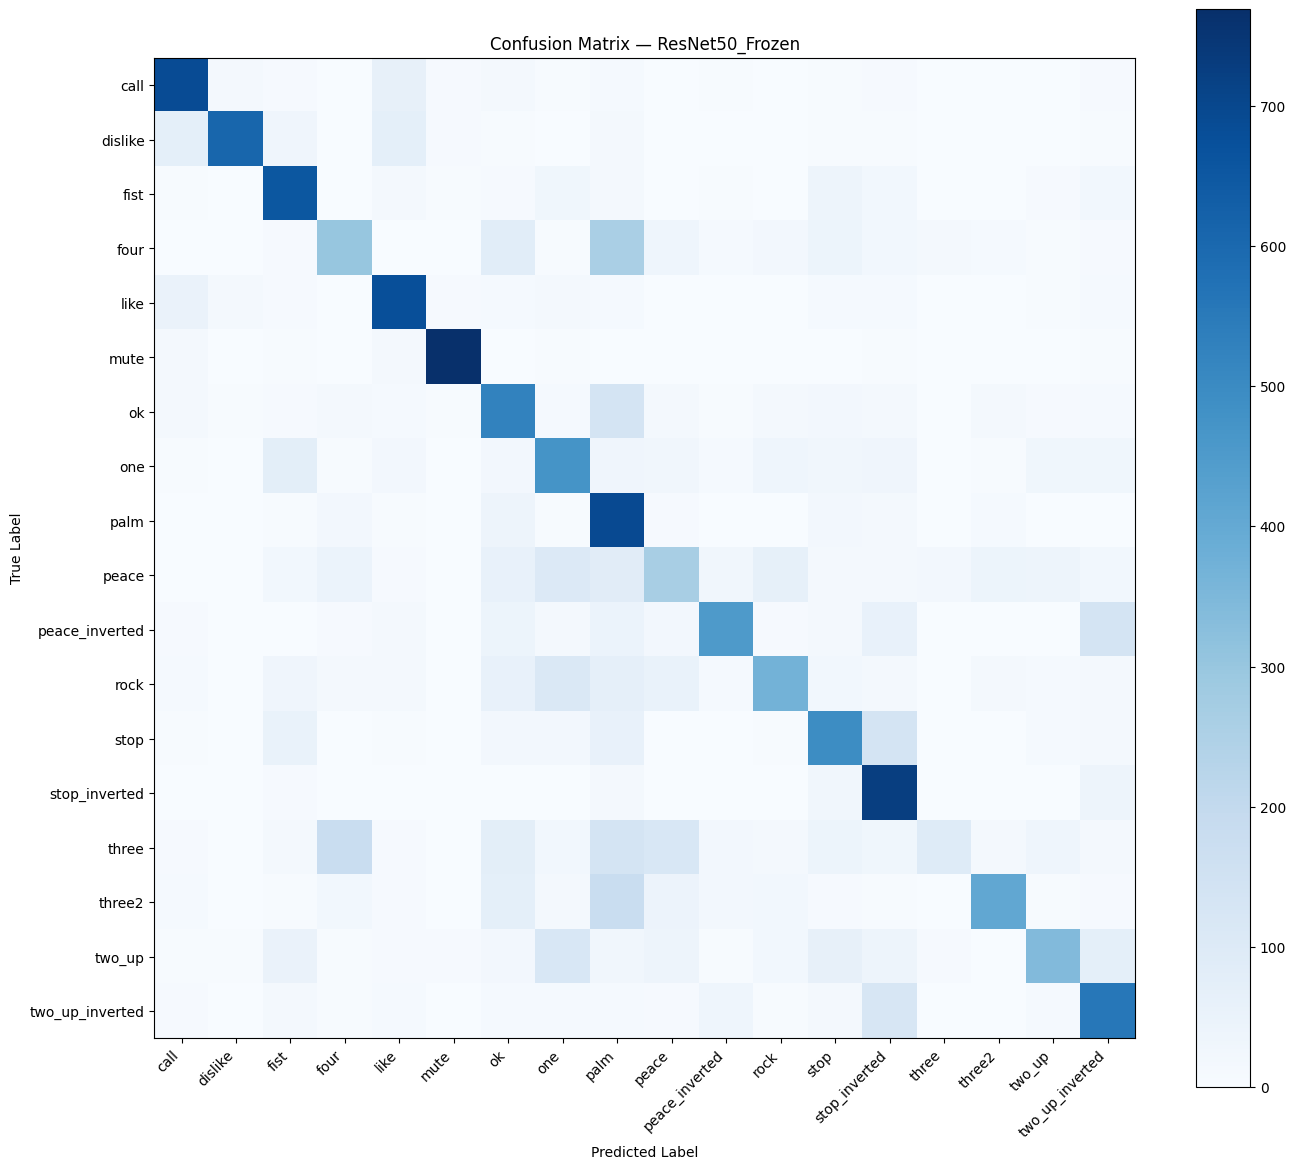

Confusion matrix saved!

Model: ResNet50_Finetune
Test Accuracy: 0.9670 (96.70%)
Macro F1 Score: 0.9673
                 precision    recall  f1-score   support

           call       0.97      0.99      0.98       834
        dislike       0.98      1.00      0.99       834
           fist       0.98      0.99      0.99       834
           four       0.96      0.93      0.95       834
           like       0.99      0.96      0.98       834
           mute       0.99      1.00      0.99       834
             ok       0.98      0.94      0.96       834
            one       0.95      0.95      0.95       834
           palm       0.99      0.96      0.98       834
          peace       0.96      0.92      0.94       834
 peace_inverted       0.99      0.97      0.98       834
           rock       0.99      0.95      0.97       834
           stop       0.99      0.96      0.97       834
  stop_inverted       0.98      0.98      0.98       834
          three       0.82      0.98    

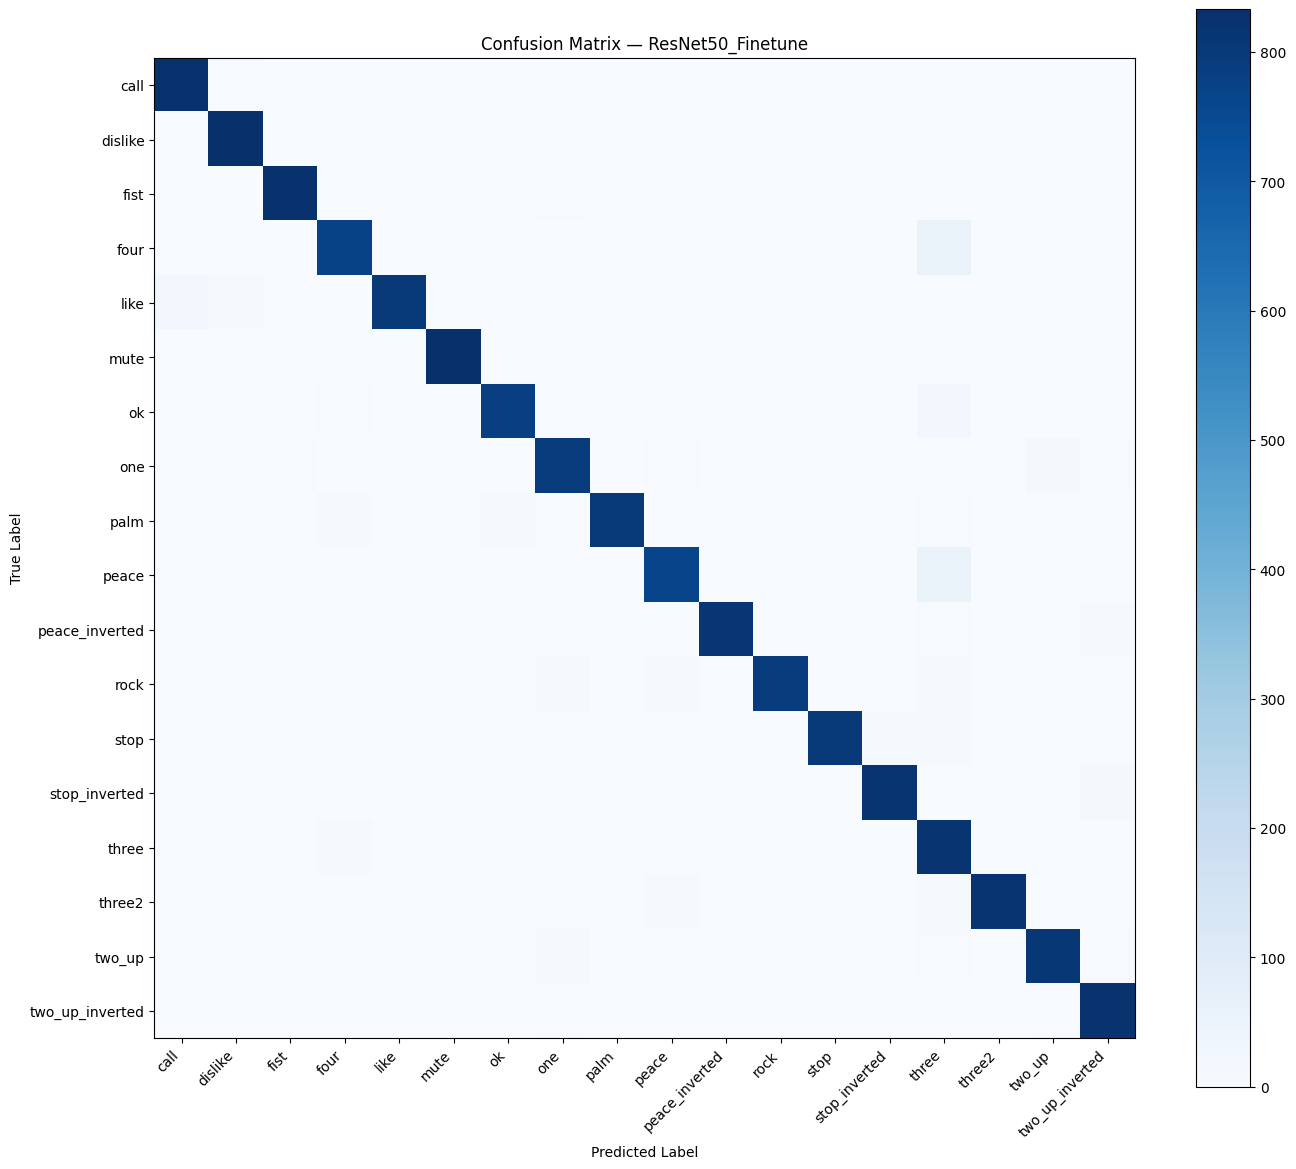

Confusion matrix saved!

Model: EfficientNet_Frozen
Test Accuracy: 0.5760 (57.60%)
Macro F1 Score: 0.5696
                 precision    recall  f1-score   support

           call       0.60      0.79      0.68       834
        dislike       0.74      0.75      0.74       834
           fist       0.66      0.68      0.67       834
           four       0.53      0.39      0.45       834
           like       0.54      0.76      0.63       834
           mute       0.77      0.89      0.83       834
             ok       0.45      0.56      0.50       834
            one       0.49      0.45      0.47       834
           palm       0.53      0.65      0.59       834
          peace       0.39      0.25      0.30       834
 peace_inverted       0.65      0.62      0.63       834
           rock       0.49      0.50      0.50       834
           stop       0.48      0.59      0.53       834
  stop_inverted       0.71      0.63      0.67       834
          three       0.39      0.35  

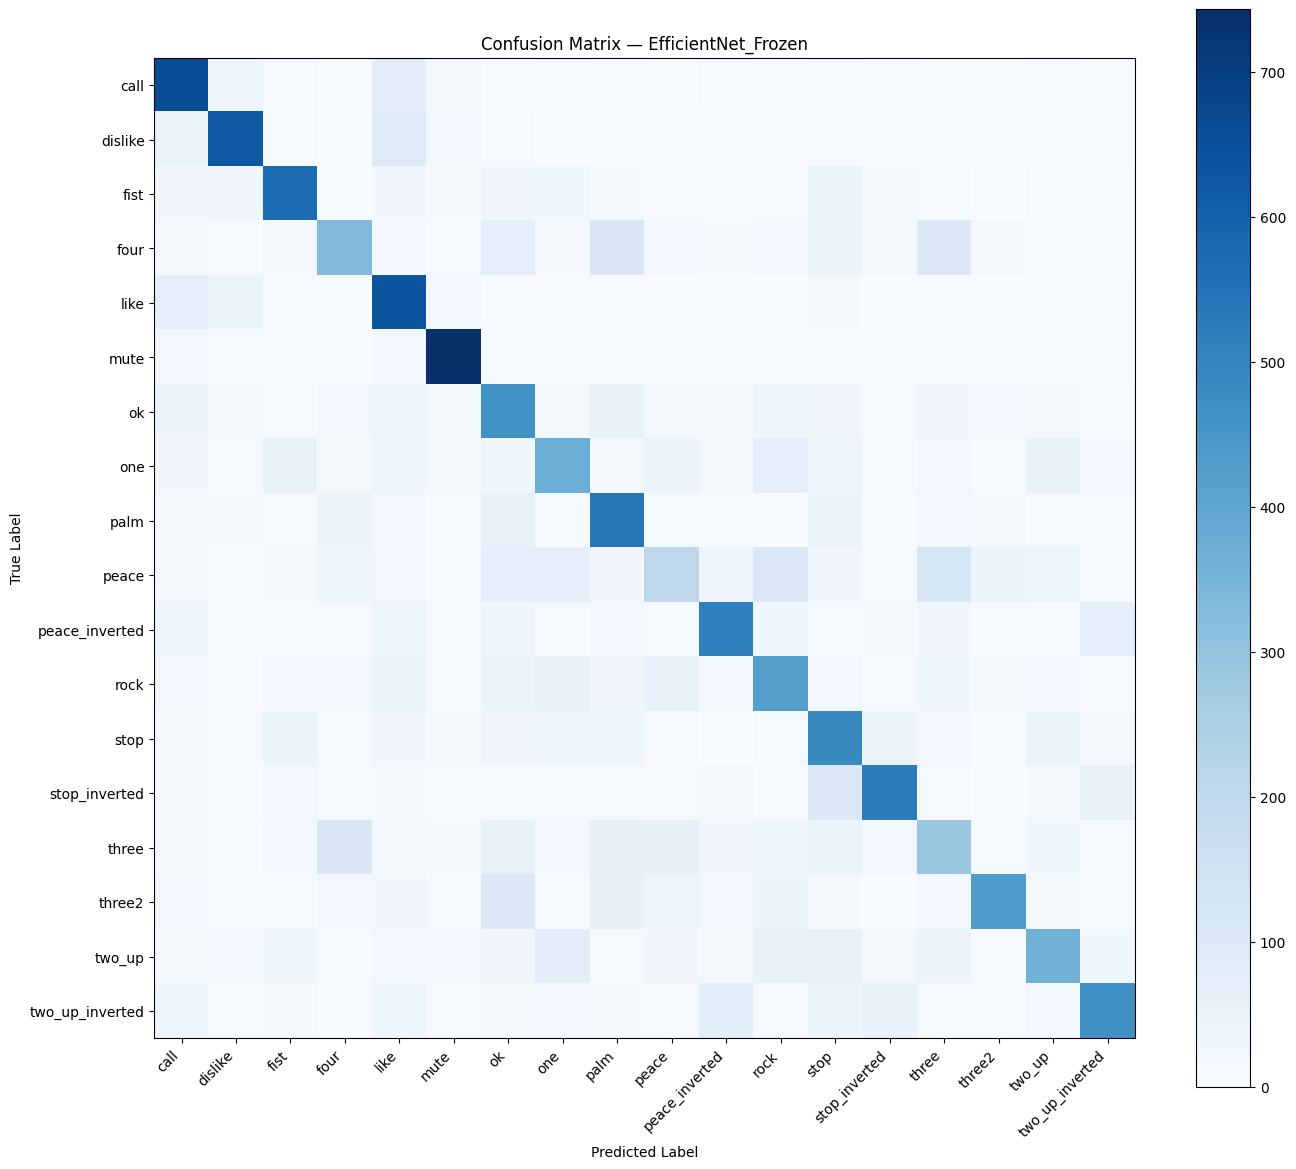

Confusion matrix saved!

Model: EfficientNet_Finetune
Test Accuracy: 0.9176 (91.76%)
Macro F1 Score: 0.9177
                 precision    recall  f1-score   support

           call       0.96      0.93      0.94       834
        dislike       0.99      0.97      0.98       834
           fist       0.95      0.95      0.95       834
           four       0.88      0.83      0.85       834
           like       0.93      0.95      0.94       834
           mute       0.98      0.98      0.98       834
             ok       0.90      0.91      0.91       834
            one       0.84      0.87      0.86       834
           palm       0.92      0.94      0.93       834
          peace       0.83      0.86      0.85       834
 peace_inverted       0.96      0.93      0.95       834
           rock       0.88      0.92      0.90       834
           stop       0.92      0.94      0.93       834
  stop_inverted       0.96      0.94      0.95       834
          three       0.82      0.83

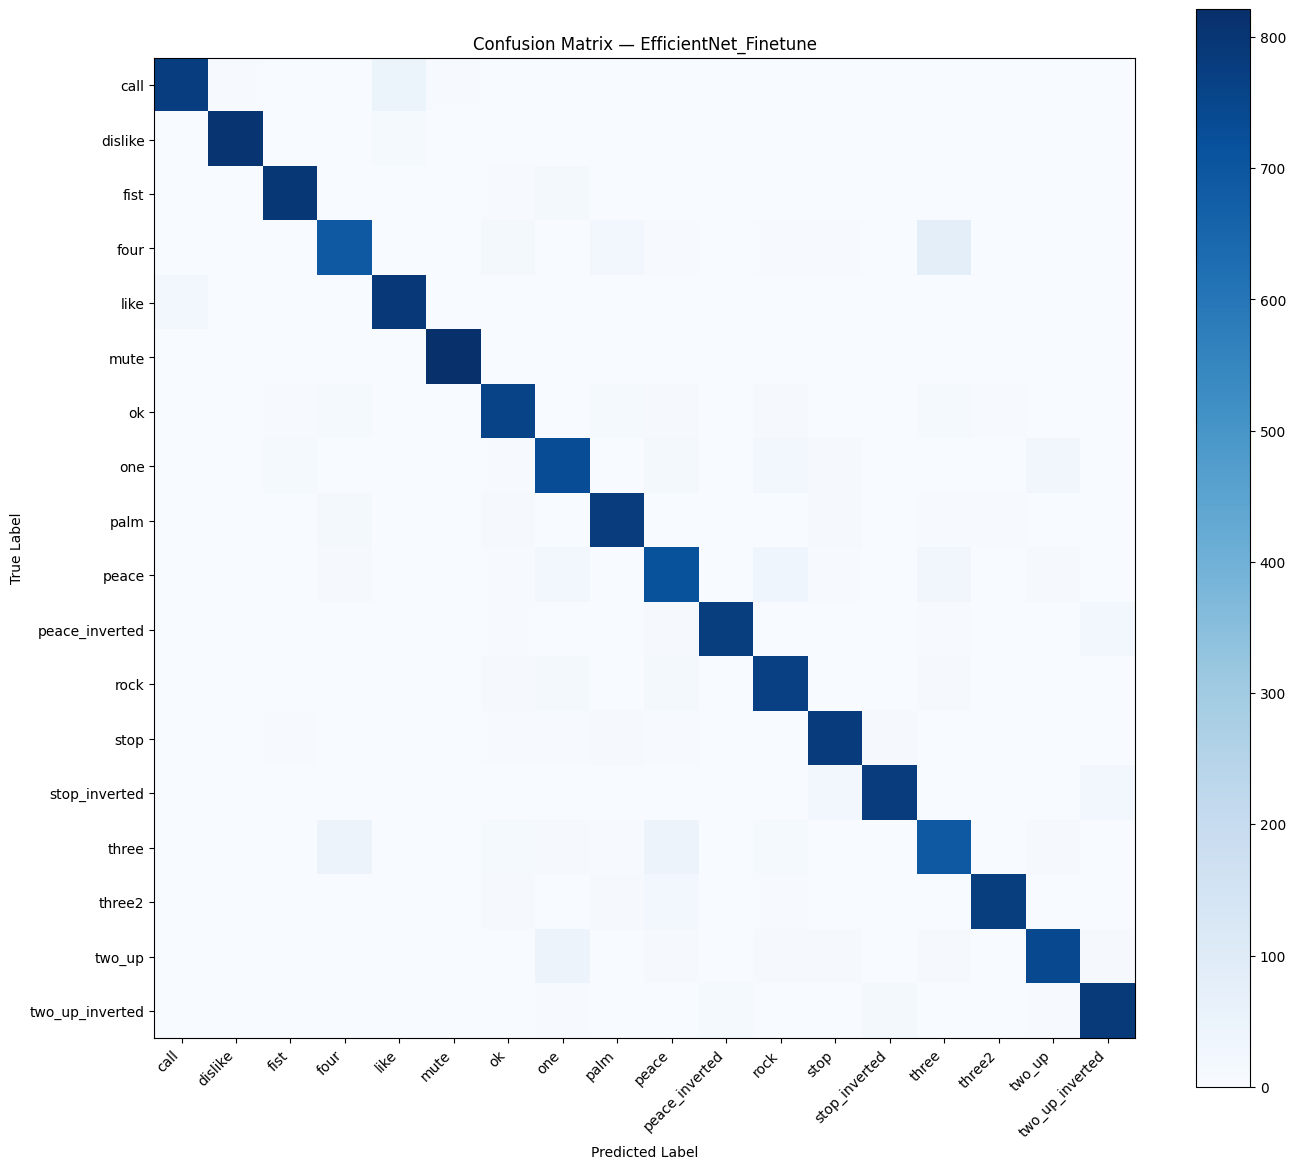

Confusion matrix saved!

FINAL SUMMARY
ResNet-50 Frozen:        Acc=0.6053  F1=0.5930
ResNet-50 Fine-tune:     Acc=0.9670  F1=0.9673
EfficientNet Frozen:     Acc=0.5760  F1=0.5696
EfficientNet Fine-tune:  Acc=0.9176  F1=0.9177


In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

def evaluate_on_test(model, loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    f1  = f1_score(all_labels, all_preds, average='macro')

    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"Macro F1 Score: {f1:.4f}")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds,
                                target_names=test_dataset.classes))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(14, 12))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.colorbar()
    tick_marks = np.arange(len(test_dataset.classes))
    plt.xticks(tick_marks, test_dataset.classes, rotation=45, ha='right')
    plt.yticks(tick_marks, test_dataset.classes)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    os.makedirs('results', exist_ok=True)
    plt.savefig(f'results/confusion_matrix_{model_name}.png', dpi=150)
    plt.show()
    print(f"Confusion matrix saved!")

    return acc, f1, all_preds, all_labels

# Evaluate all 4 models
acc_rf,  f1_rf,  _, _ = evaluate_on_test(model_frozen,    test_loader, 'ResNet50_Frozen')
acc_rft, f1_rft, _, _ = evaluate_on_test(model_finetune,  test_loader, 'ResNet50_Finetune')
acc_ef,  f1_ef,  _, _ = evaluate_on_test(model_eff_frozen, test_loader, 'EfficientNet_Frozen')
acc_eft, f1_eft, _, _ = evaluate_on_test(model_eff_ft,     test_loader, 'EfficientNet_Finetune')

# Summary
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"ResNet-50 Frozen:        Acc={acc_rf:.4f}  F1={f1_rf:.4f}")
print(f"ResNet-50 Fine-tune:     Acc={acc_rft:.4f}  F1={f1_rft:.4f}")
print(f"EfficientNet Frozen:     Acc={acc_ef:.4f}  F1={f1_ef:.4f}")
print(f"EfficientNet Fine-tune:  Acc={acc_eft:.4f}  F1={f1_eft:.4f}")

BLUR ROBUSTNESS FOR EACH MODEL

Blur Robustness Test
Model                        Clean   Blur-3   Blur-7  Blur-11
----------------------------------------------------------------------
ResNet50_Frozen             0.6053   0.5863   0.5711   0.5653
ResNet50_Finetune           0.9670   0.9630   0.9553   0.9544
EfficientNet_Frozen         0.5760   0.4972   0.4316   0.4301
EfficientNet_Finetune       0.9176   0.8958   0.8487   0.8474


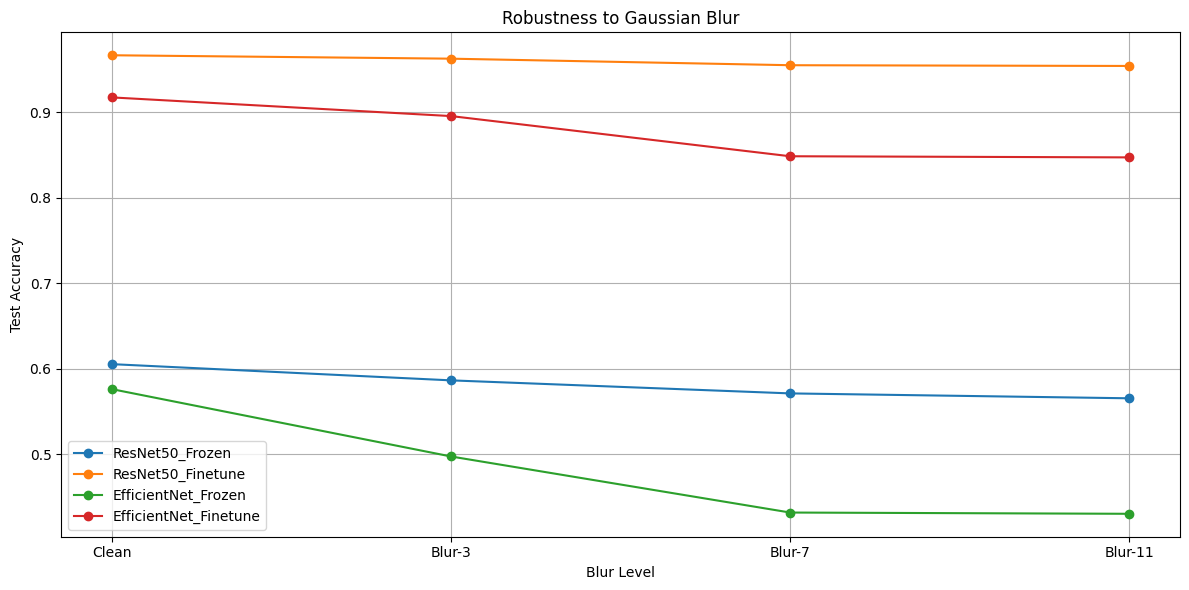

Blur robustness plot saved!


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# blur seviyeleri
blur_levels = [3, 7, 11]

def evaluate_blur(model, model_name, blur_kernel):
    blur_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.GaussianBlur(kernel_size=blur_kernel, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    blur_dataset = ImageFolder(test_dir, transform=blur_transform)
    blur_loader  = DataLoader(blur_dataset, batch_size=32,
                              shuffle=False, num_workers=4, pin_memory=True)

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in blur_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

# Test
models_dict = {
    'ResNet50_Frozen':       model_frozen,
    'ResNet50_Finetune':     model_finetune,
    'EfficientNet_Frozen':   model_eff_frozen,
    'EfficientNet_Finetune': model_eff_ft
}

blur_results = {}
print("Blur Robustness Test")
print("=" * 70)
print(f"{'Model':<25} {'Clean':>8} {'Blur-3':>8} {'Blur-7':>8} {'Blur-11':>8}")
print("-" * 70)

clean_accs = {
    'ResNet50_Frozen':       acc_rf,
    'ResNet50_Finetune':     acc_rft,
    'EfficientNet_Frozen':   acc_ef,
    'EfficientNet_Finetune': acc_eft
}

for model_name, model in models_dict.items():
    blur_results[model_name] = {}
    row = f"{model_name:<25} {clean_accs[model_name]:>8.4f}"

    for kernel in blur_levels:
        acc, f1 = evaluate_blur(model, model_name, kernel)
        blur_results[model_name][kernel] = {'acc': acc, 'f1': f1}
        row += f" {acc:>8.4f}"

    print(row)

print("=" * 70)

# Plot
plt.figure(figsize=(12, 6))
x = ['Clean', 'Blur-3', 'Blur-7', 'Blur-11']

for model_name, model in models_dict.items():
    clean = clean_accs[model_name]
    accs = [clean] + [blur_results[model_name][k]['acc'] for k in blur_levels]
    plt.plot(x, accs, marker='o', label=model_name)

plt.title('Robustness to Gaussian Blur')
plt.xlabel('Blur Level')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/blur_robustness.png', dpi=150)
plt.show()
print("Blur robustness plot saved!")

RESNETIN SON KATMANI CIKAR - VEKTORLERE PCA UYGULA BOYUTUNU AZALT - SVM UYGULA - TEST ET - SONUCLARI VER

C:\Users\husnu\AppData\Local\Temp\ipykernel_29556\88809743.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('checkpoints/resnet50_finetune_BEST.p

Extracting train embeddings...
Train embeddings: (69984, 2048)
Extracting test embeddings...
Test embeddings: (15012, 2048)

Applying PCA...
PCA done: 2048 → 200 dims
Explained variance: 99.65%

Training SVM...
SVM trained!

Evaluating SVM...

SVM Results:
Test Accuracy: 0.9768 (97.68%)
Macro F1 Score: 0.9768
                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       834
        dislike       1.00      0.99      1.00       834
           fist       0.98      0.99      0.99       834
           four       0.97      0.96      0.96       834
           like       0.98      0.98      0.98       834
           mute       0.99      1.00      0.99       834
             ok       0.97      0.96      0.97       834
            one       0.95      0.96      0.96       834
           palm       0.99      0.98      0.98       834
          peace       0.94      0.96      0.95       834
 peace_inverted       0.99      0.99      0.99       834
    

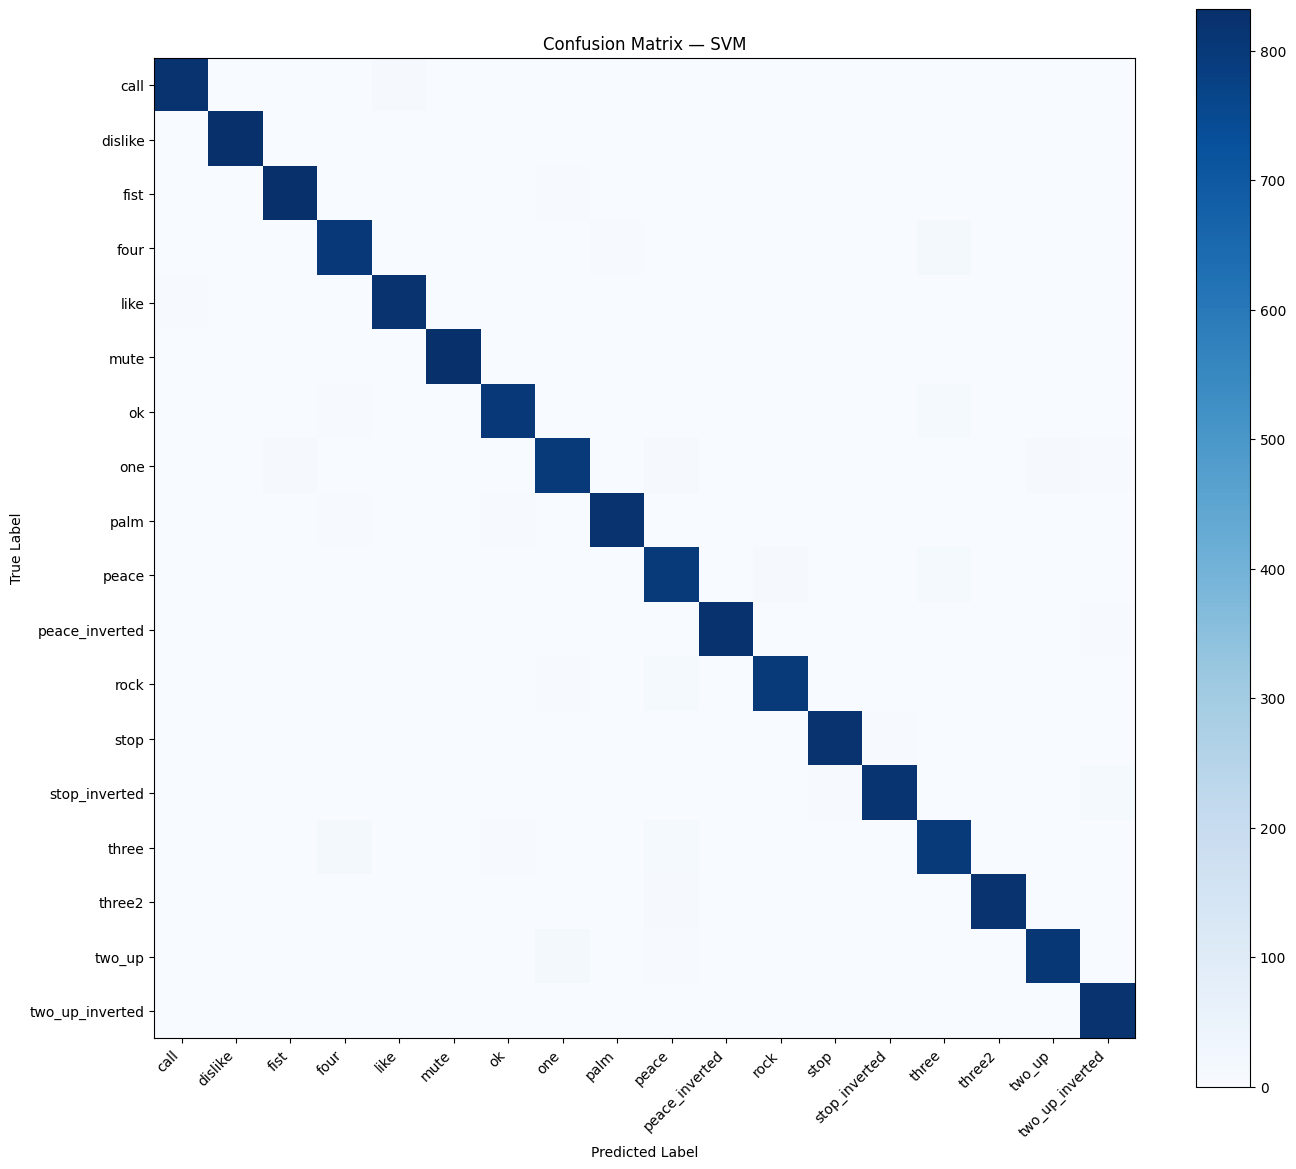


FINAL COMPARISON — ALL MODELS
Model                             Acc       F1
------------------------------------------------------------
ResNet-50 Frozen               0.6053   0.5930
ResNet-50 Fine-tune            0.9670   0.9673
EfficientNet Frozen            0.5760   0.5696
EfficientNet Fine-tune         0.9176   0.9177
SVM (ResNet embeddings)        0.9768   0.9768


In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import numpy as np


#Extract embeddings from best model (ResNet50 Finetune)


# Remove FC layer to get 2048-dim embeddings
embedding_model = models.resnet50(weights='IMAGENET1K_V1')
embedding_model.fc = nn.Identity()  #Replace FC with identity

# Load best fine-tune weights
checkpoint = torch.load('checkpoints/resnet50_finetune_BEST.pth')
state_dict = checkpoint['model_state_dict']

# Remove fc weights from state dict since we replaced it
state_dict = {k: v for k, v in state_dict.items() if not k.startswith('fc')}
embedding_model.load_state_dict(state_dict, strict=False)
embedding_model = embedding_model.to(device)
embedding_model.eval()

def extract_embeddings(loader):
    embeddings = []
    labels_list = []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = embedding_model(imgs)  # (batch, 2048)
            embeddings.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels_list)

print("Extracting train embeddings...")
train_emb, train_labels_emb = extract_embeddings(train_loader)
print(f"Train embeddings: {train_emb.shape}")

print("Extracting test embeddings...")
test_emb, test_labels_emb = extract_embeddings(test_loader)
print(f"Test embeddings: {test_emb.shape}")

# STEP 2 - PCA
print("\nApplying PCA...")
pca = PCA(n_components=200, random_state=42)
train_emb_pca = pca.fit_transform(train_emb)
test_emb_pca = pca.transform(test_emb)

explained = sum(pca.explained_variance_ratio_) * 100
print(f"PCA done: 2048 → 200 dims")
print(f"Explained variance: {explained:.2f}%")


# STEP 3 - Train SVM
print("\nTraining SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(train_emb_pca, train_labels_emb)
print("SVM trained!")


# STEP 4 - Evaluate SVM
print("\nEvaluating SVM...")
svm_preds = svm.predict(test_emb_pca)
svm_acc = accuracy_score(test_labels_emb, svm_preds)
svm_f1 = f1_score(test_labels_emb, svm_preds, average='macro')

print(f"\n{'='*50}")
print(f"SVM Results:")
print(f"Test Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)")
print(f"Macro F1 Score: {svm_f1:.4f}")
print(f"{'='*50}")
print(classification_report(test_labels_emb, svm_preds,
                            target_names=test_dataset.classes))

# Confusion matrix for SVM
cm_svm = confusion_matrix(test_labels_emb, svm_preds)
plt.figure(figsize=(14, 12))
plt.imshow(cm_svm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix — SVM')
plt.colorbar()
tick_marks = np.arange(len(test_dataset.classes))
plt.xticks(tick_marks, test_dataset.classes, rotation=45, ha='right')
plt.yticks(tick_marks, test_dataset.classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix_SVM.png', dpi=150)
plt.show()


# STEP 5 - Final Comparison Table
print("\n" + "="*60)
print("FINAL COMPARISON — ALL MODELS")
print("="*60)
print(f"{'Model':<28} {'Acc':>8} {'F1':>8}")
print("-"*60)
print(f"{'ResNet-50 Frozen':<28} {acc_rf:>8.4f} {f1_rf:>8.4f}")
print(f"{'ResNet-50 Fine-tune':<28} {acc_rft:>8.4f} {f1_rft:>8.4f}")
print(f"{'EfficientNet Frozen':<28} {acc_ef:>8.4f} {f1_ef:>8.4f}")
print(f"{'EfficientNet Fine-tune':<28} {acc_eft:>8.4f} {f1_eft:>8.4f}")
print(f"{'SVM (ResNet embeddings)':<28} {svm_acc:>8.4f} {svm_f1:>8.4f}")
print("="*60)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import timm
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# Paths
train_dir = 'split/train'
val_dir   = 'split/val'
test_dir  = 'split/test'

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir,   transform=val_test_transform)
test_dataset  = ImageFolder(test_dir,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print("Data loaders ready!")

# ============================================================
# LOAD ALL MODELS FROM CHECKPOINTS
# ============================================================

# ResNet-50 Frozen
model_frozen = models.resnet50(weights='IMAGENET1K_V1')
for param in model_frozen.parameters():
    param.requires_grad = False
model_frozen.fc = nn.Linear(model_frozen.fc.in_features, 18)
ckpt = torch.load('checkpoints/resnet50_frozen_BEST.pth', map_location=device)
model_frozen.load_state_dict(ckpt['model_state_dict'])
model_frozen = model_frozen.to(device)
model_frozen.eval()
print("ResNet-50 Frozen loaded!")

# ResNet-50 Fine-tune
model_finetune = models.resnet50(weights='IMAGENET1K_V1')
model_finetune.fc = nn.Linear(model_finetune.fc.in_features, 18)
ckpt = torch.load('checkpoints/resnet50_finetune_BEST.pth', map_location=device)
model_finetune.load_state_dict(ckpt['model_state_dict'])
model_finetune = model_finetune.to(device)
model_finetune.eval()
print("ResNet-50 Fine-tune loaded!")

# EfficientNet Frozen
model_eff_frozen = timm.create_model('efficientnet_b0', pretrained=False, num_classes=18)
ckpt = torch.load('checkpoints/efficientnet_frozen_BEST.pth', map_location=device)
model_eff_frozen.load_state_dict(ckpt['model_state_dict'])
model_eff_frozen = model_eff_frozen.to(device)
model_eff_frozen.eval()
print("EfficientNet Frozen loaded!")

# EfficientNet Fine-tune
model_eff_ft = timm.create_model('efficientnet_b0', pretrained=False, num_classes=18)
ckpt = torch.load('checkpoints/efficientnet_finetune_BEST.pth', map_location=device)
model_eff_ft.load_state_dict(ckpt['model_state_dict'])
model_eff_ft = model_eff_ft.to(device)
model_eff_ft.eval()
print("EfficientNet Fine-tune loaded!")

# Embedding model (ResNet without FC)
embedding_model = models.resnet50(weights='IMAGENET1K_V1')
embedding_model.fc = nn.Identity()
ckpt = torch.load('checkpoints/resnet50_finetune_BEST.pth', map_location=device)
state_dict = {k: v for k, v in ckpt['model_state_dict'].items() if not k.startswith('fc')}
embedding_model.load_state_dict(state_dict, strict=False)
embedding_model = embedding_model.to(device)
embedding_model.eval()
print("Embedding model loaded!")

print("\nALL MODELS READY!")

Using: cuda
✅ Data loaders ready!


C:\Users\husnu\AppData\Local\Temp\ipykernel_8140\455819414.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/resnet50_frozen_BEST.pth', map

✅ ResNet-50 Frozen loaded!


C:\Users\husnu\AppData\Local\Temp\ipykernel_8140\455819414.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/resnet50_finetune_BEST.pth', m

✅ ResNet-50 Fine-tune loaded!
✅ EfficientNet Frozen loaded!


C:\Users\husnu\AppData\Local\Temp\ipykernel_8140\455819414.py:74: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/efficientnet_frozen_BEST.pth',

✅ EfficientNet Fine-tune loaded!


C:\Users\husnu\AppData\Local\Temp\ipykernel_8140\455819414.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load('checkpoints/resnet50_finetune_BEST.pth', m

✅ Embedding model loaded!

🎉 ALL MODELS READY!


In [ ]:
def extract_embeddings(loader):
    embeddings, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = embedding_model(imgs)
            embeddings.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels_list)

print("Extracting train embeddings...")
train_emb, train_labels_emb = extract_embeddings(train_loader)

print("Extracting test embeddings...")
test_emb, test_labels_emb = extract_embeddings(test_loader)

print("Applying PCA...")
pca = PCA(n_components=200, random_state=42)
train_emb_pca = pca.fit_transform(train_emb)
test_emb_pca  = pca.transform(test_emb)
explained = sum(pca.explained_variance_ratio_) * 100
print(f"PCA done. Explained variance: {explained:.2f}%")

print("Training SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(train_emb_pca, train_labels_emb)
svm_preds = svm.predict(test_emb_pca)
svm_acc   = accuracy_score(test_labels_emb, svm_preds)
svm_f1    = f1_score(test_labels_emb, svm_preds, average='macro')
print(f"SVM ready! Acc={svm_acc:.4f} F1={svm_f1:.4f}")

Extracting train embeddings...
Extracting test embeddings...
Applying PCA...
✅ PCA done. Explained variance: 99.65%
Training SVM...
✅ SVM ready! Acc=0.9760 F1=0.9760


In [ ]:
blur_levels = [3, 7, 11]

def extract_blur_embeddings(blur_kernel):
    blur_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.GaussianBlur(kernel_size=blur_kernel, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    blur_dataset = ImageFolder(test_dir, transform=blur_transform)
    blur_loader  = DataLoader(blur_dataset, batch_size=32, shuffle=False,
                              num_workers=4, pin_memory=True)
    embeddings, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in blur_loader:
            imgs = imgs.to(device)
            feats = embedding_model(imgs)
            embeddings.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels_list)

print("SVM Robustness to Gaussian Blur:")
print("="*55)
print(f"{'Blur Level':<15} {'Accuracy':>10} {'Macro F1':>10}")
print("-"*55)
print(f"{'Clean':<15} {svm_acc:>10.4f} {svm_f1:>10.4f}")

svm_blur_results = {}
for kernel in blur_levels:
    emb, labels = extract_blur_embeddings(kernel)
    emb_pca = pca.transform(emb)
    preds = svm.predict(emb_pca)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro')
    svm_blur_results[kernel] = {'acc': acc, 'f1': f1}
    print(f"{'Blur-'+str(kernel):<15} {acc:>10.4f} {f1:>10.4f}")

print("="*55)

SVM Robustness to Gaussian Blur:
Blur Level        Accuracy   Macro F1
-------------------------------------------------------
Clean               0.9760     0.9760
Blur-3              0.9725     0.9725
Blur-7              0.9630     0.9631
Blur-11             0.9649     0.9650


In [ ]:
from itertools import product
from torch.utils.data import DataLoader

learning_rates = [1e-3, 1e-4, 1e-5]
batch_sizes    = [32, 64]
optimizers     = ['Adam', 'SGD']

TUNE_EPOCHS = 3  # Quick search — 3 epochs per config

print("HYPERPARAMETER TUNING — ResNet-50 Fine-tune")
print("="*75)
print(f"{'LR':<10} {'Batch':>6} {'Optimizer':>10} {'Val Acc (ep1)':>14} {'Val Acc (ep3)':>14}")
print("-"*75)

tuning_results = []

for lr, bs, opt_name in product(learning_rates, batch_sizes, optimizers):
    # Build loaders with this batch size
    tune_train_loader = DataLoader(train_dataset, batch_size=bs,
                                   shuffle=True, num_workers=4, pin_memory=True)
    tune_val_loader   = DataLoader(val_dataset, batch_size=bs,
                                   shuffle=False, num_workers=4, pin_memory=True)

    # Build model
    tune_model = models.resnet50(weights='IMAGENET1K_V1')
    tune_model.fc = nn.Linear(tune_model.fc.in_features, 18)
    for param in tune_model.parameters():
        param.requires_grad = False
    for param in tune_model.layer4.parameters():
        param.requires_grad = True
    for param in tune_model.fc.parameters():
        param.requires_grad = True
    tune_model = tune_model.to(device)

    # Build optimizer
    params = [
        {'params': tune_model.layer4.parameters(), 'lr': lr * 0.1},
        {'params': tune_model.fc.parameters(),     'lr': lr}
    ]
    if opt_name == 'Adam':
        optimizer_tune = torch.optim.Adam(params)
    else:
        optimizer_tune = torch.optim.SGD(params, momentum=0.9)

    ep1_acc, ep3_acc = 0, 0
    for epoch in range(TUNE_EPOCHS):
        train_one_epoch(tune_model, tune_train_loader, optimizer_tune)
        _, val_acc = evaluate(tune_model, tune_val_loader)
        if epoch == 0:
            ep1_acc = val_acc
        if epoch == TUNE_EPOCHS - 1:
            ep3_acc = val_acc

    tuning_results.append({
        'lr': lr, 'batch': bs, 'optimizer': opt_name,
        'ep1': ep1_acc, 'ep3': ep3_acc
    })
    print(f"{str(lr):<10} {bs:>6} {opt_name:>10} {ep1_acc:>14.4f} {ep3_acc:>14.4f}")

print("="*75)
best = max(tuning_results, key=lambda x: x['ep3'])
print(f"\nBest config: LR={best['lr']}, Batch={best['batch']}, "
      f"Optimizer={best['optimizer']}, Val Acc={best['ep3']:.4f}")

HYPERPARAMETER TUNING — ResNet-50 Fine-tune
LR          Batch  Optimizer  Val Acc (ep1)  Val Acc (ep3)
---------------------------------------------------------------------------
0.001          32       Adam         0.9503         0.9649
0.001          32        SGD         0.8307         0.9176
0.001          64       Adam         0.9483         0.9641
0.001          64        SGD         0.7230         0.8756
0.0001         32       Adam         0.9230         0.9532
0.0001         32        SGD         0.3648         0.6223
0.0001         64       Adam         0.9055         0.9452
0.0001         64        SGD         0.2630         0.4506
1e-05          32       Adam         0.5892         0.8423
1e-05          32        SGD         0.1103         0.1971
1e-05          64       Adam         0.4408         0.7888
1e-05          64        SGD         0.0753         0.1343

Best config: LR=0.001, Batch=32, Optimizer=Adam, Val Acc=0.9649


In [ ]:
import pandas as pd

classes = test_dataset.classes

def get_classwise_acc(model, blur_kernel=None):
    if blur_kernel:
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.GaussianBlur(kernel_size=blur_kernel, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        dataset = ImageFolder(test_dir, transform=transform)
    else:
        dataset = ImageFolder(test_dir, transform=val_test_transform)

    loader = DataLoader(dataset, batch_size=32, shuffle=False,
                        num_workers=4, pin_memory=True)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Per-class accuracy
    per_class = {}
    for cls_idx, cls_name in enumerate(classes):
        mask = [l == cls_idx for l in all_labels]
        correct = sum(p == l for p, l in zip(all_preds, all_labels) if l == cls_idx)
        total   = sum(mask)
        per_class[cls_name] = correct / total if total > 0 else 0
    return per_class

print("CLASS-WISE ROBUSTNESS ANALYSIS — ResNet-50 Fine-tune")
print("="*80)
print(f"{'Class':<20} {'Clean':>8} {'Blur-3':>8} {'Blur-7':>8} {'Blur-11':>8} {'Drop':>8}")
print("-"*80)

clean_cw   = get_classwise_acc(model_finetune)
blur3_cw   = get_classwise_acc(model_finetune, 3)
blur7_cw   = get_classwise_acc(model_finetune, 7)
blur11_cw  = get_classwise_acc(model_finetune, 11)

for cls in classes:
    drop = blur11_cw[cls] - clean_cw[cls]
    print(f"{cls:<20} {clean_cw[cls]:>8.4f} {blur3_cw[cls]:>8.4f} "
          f"{blur7_cw[cls]:>8.4f} {blur11_cw[cls]:>8.4f} {drop:>+8.4f}")

print("="*80)
most_robust     = max(classes, key=lambda c: blur11_cw[c] - clean_cw[c])
least_robust    = min(classes, key=lambda c: blur11_cw[c] - clean_cw[c])
print(f"\nMost robust class:  {most_robust} "
      f"(drop: {blur11_cw[most_robust]-clean_cw[most_robust]:+.4f})")
print(f"Least robust class: {least_robust} "
      f"(drop: {blur11_cw[least_robust]-clean_cw[least_robust]:+.4f})")

CLASS-WISE ROBUSTNESS ANALYSIS — ResNet-50 Fine-tune
Class                   Clean   Blur-3   Blur-7  Blur-11     Drop
--------------------------------------------------------------------------------
call                   0.9832   0.9712   0.9580   0.9640  -0.0192
dislike                0.9760   0.9772   0.9724   0.9748  -0.0012
fist                   0.9796   0.9832   0.9784   0.9856  +0.0060
four                   0.9688   0.9616   0.9556   0.9556  -0.0132
like                   0.9724   0.9760   0.9760   0.9724  +0.0000
mute                   1.0000   1.0000   1.0000   0.9988  -0.0012
ok                     0.9484   0.9508   0.9436   0.9424  -0.0060
one                    0.9496   0.9472   0.9365   0.9281  -0.0216
palm                   0.9844   0.9736   0.9760   0.9712  -0.0132
peace                  0.9269   0.9113   0.9029   0.8897  -0.0372
peace_inverted         0.9868   0.9796   0.9712   0.9664  -0.0204
rock                   0.9760   0.9676   0.9568   0.9628  -0.0132
stop    

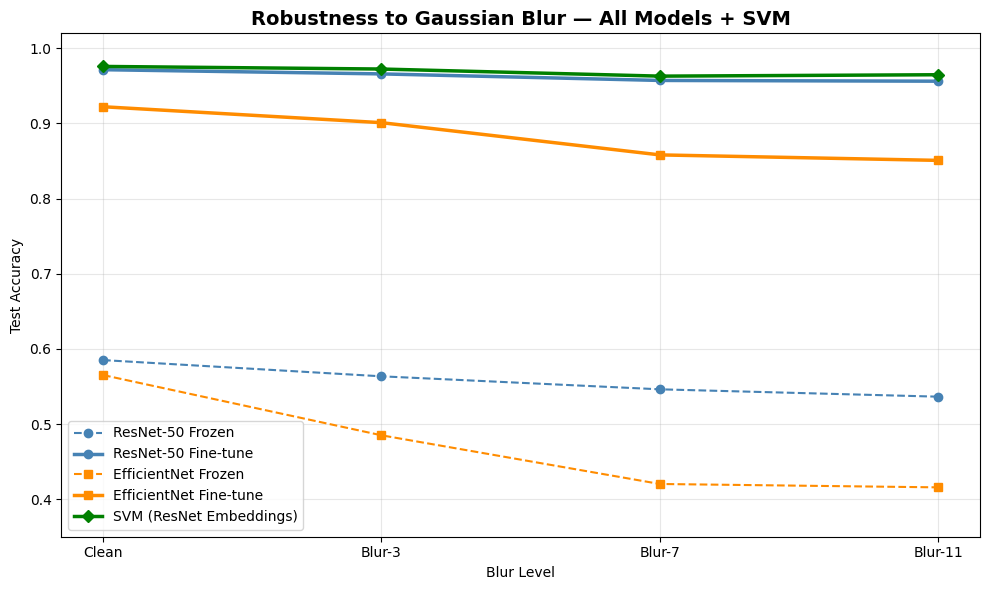

Plot 1 saved!


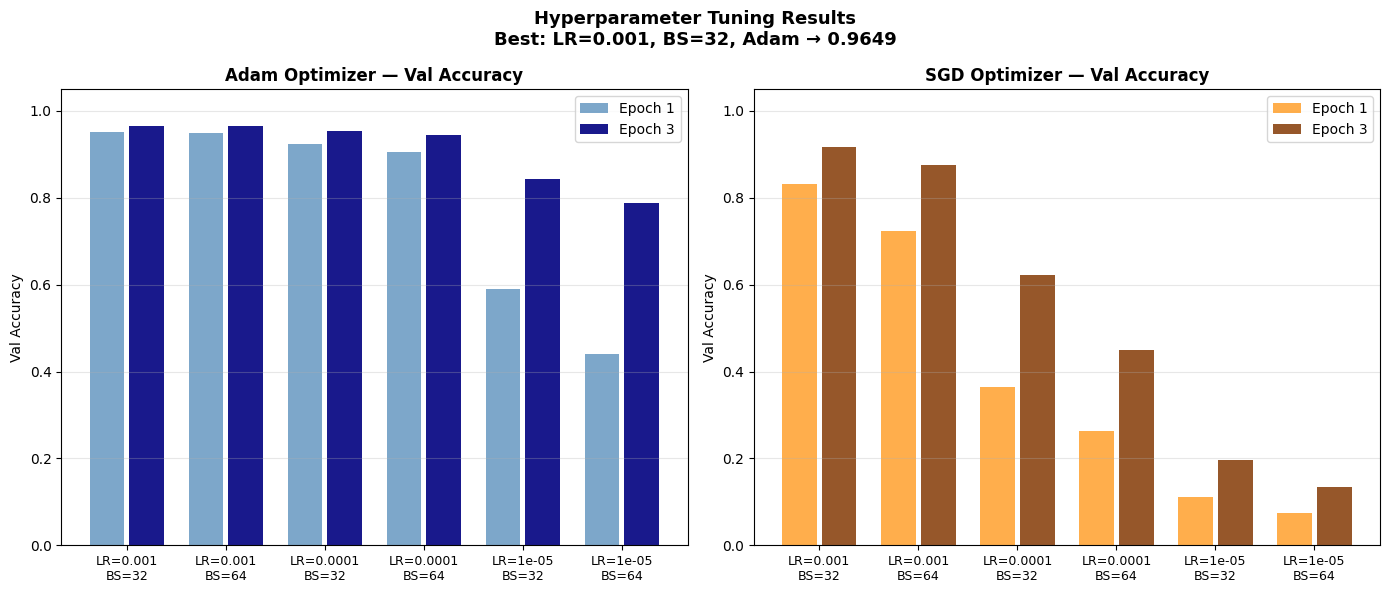

Plot 2 saved!


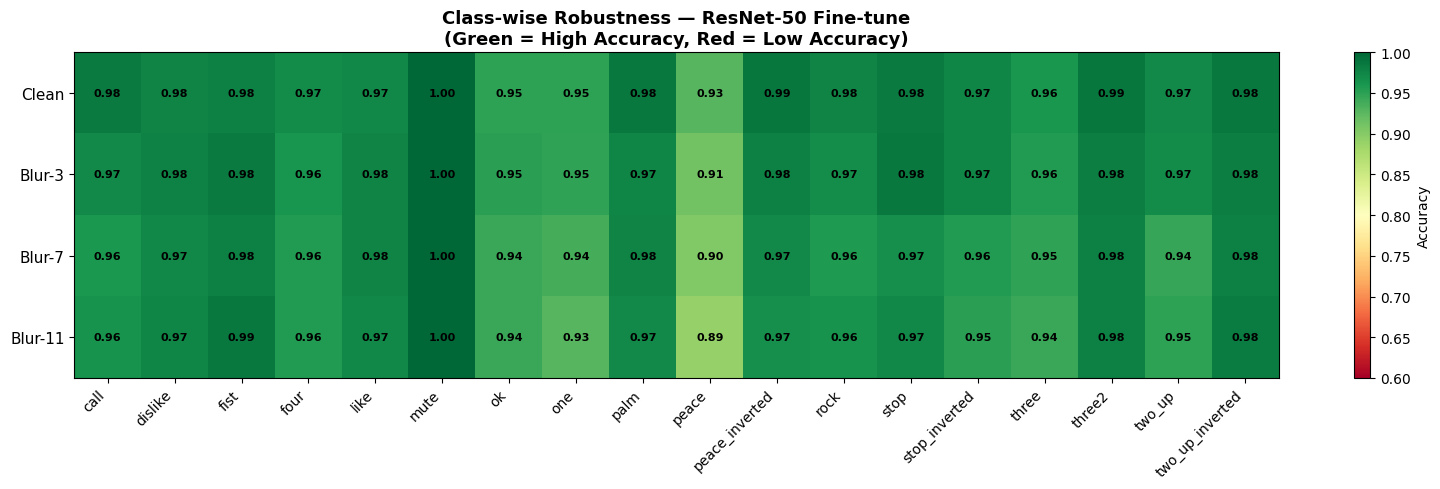

Plot 3 saved!


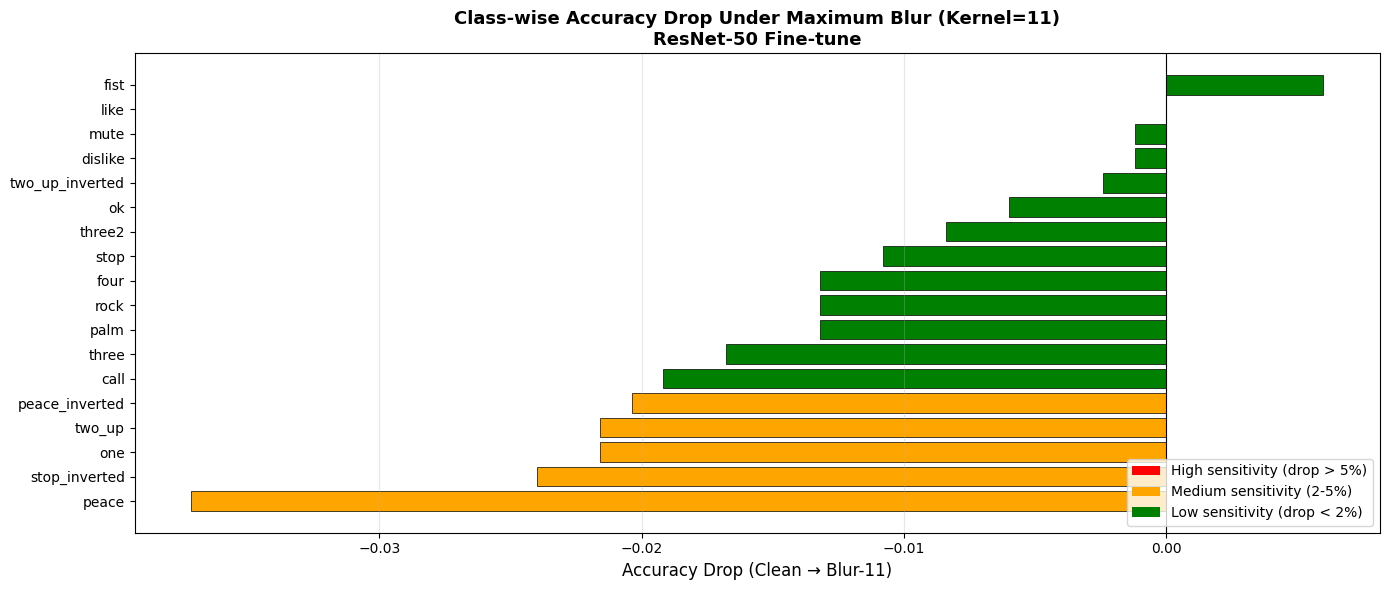

Plot 4 saved!

ALL PLOTS SAVED to results/ folder!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PLOT 1 — SVM Blur Robustness vs DL Models
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

x = ['Clean', 'Blur-3', 'Blur-7', 'Blur-11']

# DL Models (from your results)
resnet_frozen   = [0.5851, 0.5635, 0.5462, 0.5364]
resnet_ft       = [0.9716, 0.9660, 0.9573, 0.9563]
eff_frozen      = [0.5652, 0.4850, 0.4202, 0.4157]
eff_ft          = [0.9223, 0.9011, 0.8582, 0.8509]

# SVM blur results — fill after running Cell 1
svm_blur = [svm_acc,
            svm_blur_results[3]['acc'],
            svm_blur_results[7]['acc'],
            svm_blur_results[11]['acc']]

ax.plot(x, resnet_frozen, marker='o', linestyle='--', color='steelblue',   label='ResNet-50 Frozen')
ax.plot(x, resnet_ft,     marker='o', linestyle='-',  color='steelblue',   label='ResNet-50 Fine-tune', linewidth=2.5)
ax.plot(x, eff_frozen,    marker='s', linestyle='--', color='darkorange',  label='EfficientNet Frozen')
ax.plot(x, eff_ft,        marker='s', linestyle='-',  color='darkorange',  label='EfficientNet Fine-tune', linewidth=2.5)
ax.plot(x, svm_blur,      marker='D', linestyle='-',  color='green',       label='SVM (ResNet Embeddings)', linewidth=2.5)

ax.set_title('Robustness to Gaussian Blur — All Models + SVM', fontsize=14, fontweight='bold')
ax.set_xlabel('Blur Level')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0.35, 1.02)
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/blur_robustness_with_svm.png', dpi=150)
plt.show()
print("Plot 1 saved!")

# ============================================================
# PLOT 2 — Hyperparameter Tuning Results
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Group by optimizer
adam_results = [r for r in tuning_results if r['optimizer'] == 'Adam']
sgd_results  = [r for r in tuning_results if r['optimizer'] == 'SGD']

def make_label(r):
    return f"LR={r['lr']}\nBS={r['batch']}"

# Adam subplot
adam_labels = [make_label(r) for r in adam_results]
adam_ep1    = [r['ep1'] for r in adam_results]
adam_ep3    = [r['ep3'] for r in adam_results]
x_pos = np.arange(len(adam_labels))

axes[0].bar(x_pos - 0.2, adam_ep1, 0.35, label='Epoch 1', color='steelblue', alpha=0.7)
axes[0].bar(x_pos + 0.2, adam_ep3, 0.35, label='Epoch 3', color='navy', alpha=0.9)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(adam_labels, fontsize=9)
axes[0].set_title('Adam Optimizer — Val Accuracy', fontweight='bold')
axes[0].set_ylabel('Val Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# SGD subplot
sgd_labels = [make_label(r) for r in sgd_results]
sgd_ep1    = [r['ep1'] for r in sgd_results]
sgd_ep3    = [r['ep3'] for r in sgd_results]
x_pos2 = np.arange(len(sgd_labels))

axes[1].bar(x_pos2 - 0.2, sgd_ep1, 0.35, label='Epoch 1', color='darkorange', alpha=0.7)
axes[1].bar(x_pos2 + 0.2, sgd_ep3, 0.35, label='Epoch 3', color='saddlebrown', alpha=0.9)
axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels(sgd_labels, fontsize=9)
axes[1].set_title('SGD Optimizer — Val Accuracy', fontweight='bold')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Highlight best config
best_label = f"Best: LR={best['lr']}, BS={best['batch']}, {best['optimizer']} → {best['ep3']:.4f}"
fig.suptitle(f'Hyperparameter Tuning Results\n{best_label}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/hyperparameter_tuning.png', dpi=150)
plt.show()
print("Plot 2 saved!")

# ============================================================
# PLOT 3 — Class-wise Robustness Heatmap
# ============================================================
classes_list = list(clean_cw.keys())

data = np.array([
    [clean_cw[c]  for c in classes_list],
    [blur3_cw[c]  for c in classes_list],
    [blur7_cw[c]  for c in classes_list],
    [blur11_cw[c] for c in classes_list],
])

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0.6, vmax=1.0)

ax.set_xticks(range(len(classes_list)))
ax.set_xticklabels(classes_list, rotation=45, ha='right', fontsize=10)
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(['Clean', 'Blur-3', 'Blur-7', 'Blur-11'], fontsize=11)
ax.set_title('Class-wise Robustness — ResNet-50 Fine-tune\n(Green = High Accuracy, Red = Low Accuracy)',
             fontsize=13, fontweight='bold')

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f'{data[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black', fontweight='bold')

plt.colorbar(im, ax=ax, label='Accuracy')
plt.tight_layout()
plt.savefig('results/classwise_robustness_heatmap.png', dpi=150)
plt.show()
print("Plot 3 saved!")

# ============================================================
# PLOT 4 — Class Drop Bar Chart (Most vs Least Robust)
# ============================================================
drops = {c: blur11_cw[c] - clean_cw[c] for c in classes_list}
sorted_classes = sorted(drops.keys(), key=lambda c: drops[c])
sorted_drops   = [drops[c] for c in sorted_classes]
colors = ['red' if d < -0.05 else 'orange' if d < -0.02 else 'green' for d in sorted_drops]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(sorted_classes, sorted_drops, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Accuracy Drop (Clean → Blur-11)', fontsize=12)
ax.set_title('Class-wise Accuracy Drop Under Maximum Blur (Kernel=11)\nResNet-50 Fine-tune',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red',    label='High sensitivity (drop > 5%)'),
    Patch(facecolor='orange', label='Medium sensitivity (2-5%)'),
    Patch(facecolor='green',  label='Low sensitivity (drop < 2%)')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('results/classwise_drop_chart.png', dpi=150)
plt.show()
print("Plot 4 saved!")

print("\nALL PLOTS SAVED to results/ folder!")